# 03 - Linear Regression Model
 Crop Productivity Prediction Project

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

# Load cleaned data
data_agri = pd.read_csv('../data/cleaned_agriculture_data.csv')
data_agri.head()

,Crop,Prod2011,Prod2012,Prod2013,Prod2014,Prod2015,Area2011,Area2012,Area2013,Area2014,Area2015,Yield2011,Yield2012,Yield2013,Yield2014,Yield2015,Weather,Season
0,Total Foodgrains,158.8,168.6,171.3,159.40,178.9,128.5,128.8,127.6,126.0,131.7,123.6,130.9,134.3,126.5,135.9,Rainy,Kharif
1,Rice,200.8,207.9,213.3,191.60,206.4,168.5,168.9,175.1,161.2,164.8,119.2,123.1,121.8,118.9,125.2,Overcast,Rabi
2,Wheat,131.6,136.4,140.1,140.30,150.8,115.0,115.2,114.0,116.9,119.5,114.4,118.4,122.8,120.0,126.3,Overcast,Kharif
3,Jowar,124.3,137.8,126.0,116.50,121.8,120.7,110.6,107.3,111.0,105.2,103.0,124.6,117.4,105.0,115.8,Sunny,Rabi
4,Bajra,136.4,161.5,143.9,146.95,167.9,94.5,95.1,87.0,88.5,95.6,144.3,169.7,165.4,119.0,175.8,Rainy,Rabi


In [2]:
# Selecting Features and Target
X = data_agri[['Area2011','Area2012','Area2013','Area2014','Area2015',
               'Yield2011','Yield2012','Yield2013','Yield2014','Yield2015']]
y = data_agri['Prod2015']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (54, 10)
Target shape: (54,)


In [3]:
# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (37, 10)
Testing size: (17, 10)


In [4]:
# Training the Linear Regression Model
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model trained successfully!")
print("Intercept:", lm.intercept_)

Model trained successfully!
Intercept: -148.13482733329084


In [5]:
# Model Coefficients
cdf = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print(cdf)

           Coefficient
Area2011      0.110921
Area2012     -0.722236
Area2013      0.321524
Area2014     -0.073055
Area2015      1.681248
Yield2011    -0.011890
Yield2012     0.528111
Yield2013    -0.028701
Yield2014    -0.209330
Yield2015     0.840778


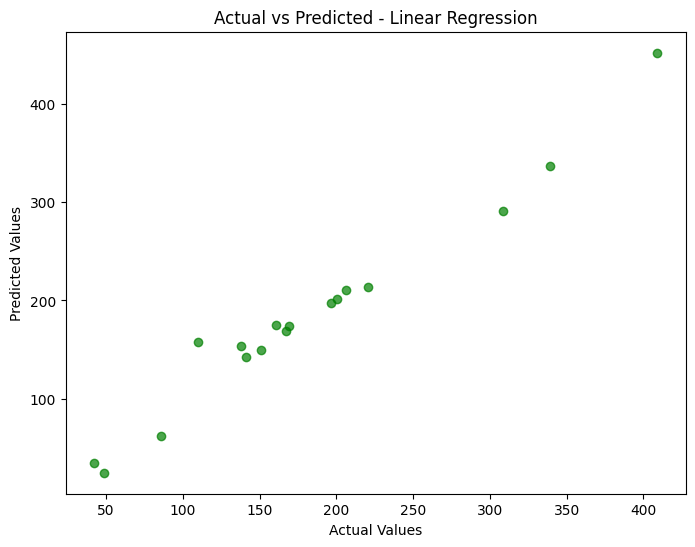

In [6]:
# Predictions
prediction = lm.predict(X_test)

# Scatter plot - Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, prediction, alpha=0.7, color='green')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

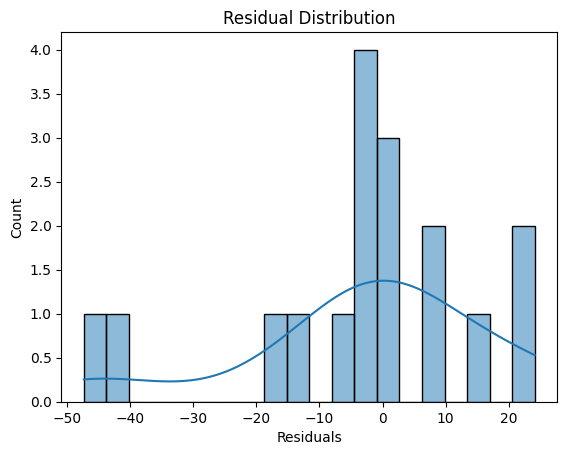

In [7]:
# Residual Plot
sns.histplot((y_test - prediction), bins=20, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

In [8]:
# Model Evaluation
print("Model Evaluation Metrics:")
print("MAE  -->", metrics.mean_absolute_error(y_test, prediction))
print("MSE  -->", metrics.mean_squared_error(y_test, prediction))
print("RMSE -->", np.sqrt(metrics.mean_squared_error(y_test, prediction)))
print("R²   -->", metrics.explained_variance_score(y_test, prediction))

Model Evaluation Metrics:
MAE  --> 12.871013097611137
MSE  --> 361.6184707786713
RMSE --> 19.016268581892486
R²   --> 0.960601428159721
